In [1]:
import sys
sys.path.append("..")

from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

from LeastSquaresQNN import LSQNN
from ConvexQNN import QNN

In [70]:
X, Y = make_regression(n_samples=1000, n_features=10, n_informative=5, n_targets=1, noise=10, random_state=1)
Y = np.expand_dims(Y, axis=1)

X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X = (X - X_mean)/X_std
Y_mean = np.mean(Y, axis=0)
Y_std = np.std(Y, axis=0)
Y = (Y - Y_mean)/Y_std

beta_list = np.logspace(-9,0,10)

loss_reg_cvx_list = []
loss_reg_qnn_list = []
loss_dat_cvx_list = []
loss_dat_qnn_list = []
loss_cvx_list = []
loss_qnn_list = []

for beta in beta_list:
    lsqnn = LSQNN()
    loss_qnn = lsqnn.Train(X, Y, beta=beta, return_loss=True)
    loss_reg_qnn = beta*(lsqnn.weights.T @ lsqnn.weights)[0,0]

    Z, _, _, loss_cvx = QNN(X, Y, beta=beta, return_loss=True, verbose=False)
    loss_cvx = loss_cvx**2
    loss_reg_cvx = beta*np.abs(Z[-1,-1,0]/0.4688)

    loss_reg_cvx_list.append(loss_reg_cvx)
    loss_reg_qnn_list.append(loss_reg_qnn)
    loss_dat_cvx_list.append(loss_cvx-loss_reg_cvx)
    loss_dat_qnn_list.append(loss_qnn-loss_reg_qnn)
    loss_cvx_list.append(loss_cvx)
    loss_qnn_list.append(loss_qnn)

c:\Users\zacha\AppData\Local\Programs\Python\Python312\Lib\site-packages\cvxpy\problems\problem.py:158: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn("Objective contains too many subexpressions. "
c:\Users\zacha\AppData\Local\Programs\Python\Python312\Lib\site-packages\cvxpy\problems\problem.py:164: UserWarning: Constraint #0 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


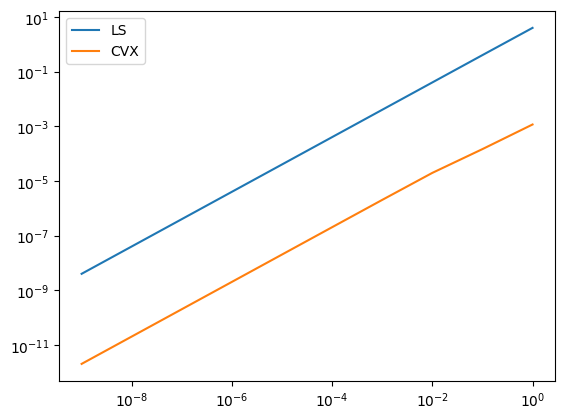

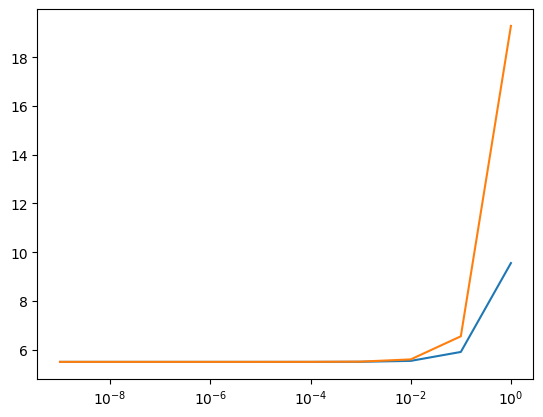

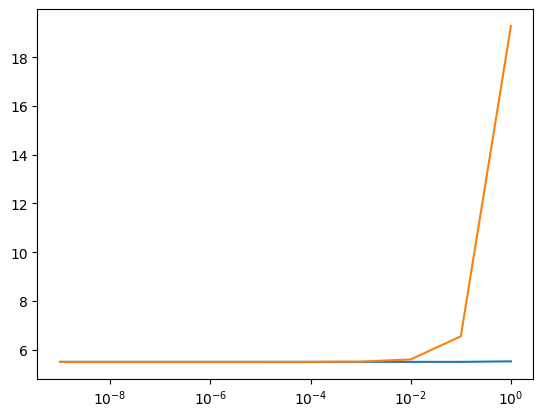

In [72]:
%matplotlib inline
plt.xscale("log")
plt.yscale("log")
plt.plot(beta_list, loss_reg_qnn_list, label="LS")
plt.plot(beta_list, loss_reg_cvx_list, label="CVX")
plt.legend()

plt.figure()
plt.xscale("log")
plt.plot(beta_list, loss_qnn_list)
plt.plot(beta_list, loss_cvx_list)

plt.figure()
plt.xscale("log")
plt.plot(beta_list, loss_dat_qnn_list)
plt.plot(beta_list, loss_dat_cvx_list)